In [1]:
from pathlib import Path

CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CWD, *CWD.parents)
     if (candidate / 'analyses').is_dir() and (candidate / 'bases').is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto.')

DATA_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '01_dados'
OUTPUT_DIR = DATA_DIR

# 04 — Análise Exploratória dos Dados (EDA)
**Grupo 1 | Séries Temporais**

Análise exploratória aprofundada da série de preço do Bitcoin, incluindo distribuições, sazonalidades, comportamento de variáveis externas e autocorrelações.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 11
})

RANDOM_STATE = 42
TRAIN_RATIO  = 0.70

In [3]:
df = pd.read_csv(DATA_DIR / 'bitcoin_limpo.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'Base: {df.shape} | {df["date"].min().date()} → {df["date"].max().date()}')

n = len(df)
n_train = int(n * TRAIN_RATIO)
df_train = df.iloc[:n_train].copy()
df_test  = df.iloc[n_train:].copy()
data_corte = df.iloc[n_train]['date']

print(f'Treino: {n_train} obs | Teste: {n - n_train} obs | Corte: {data_corte.date()}')

Base: (2943, 10) | 2018-08-22 → 2026-09-11
Treino: 2060 obs | Teste: 883 obs | Corte: 2024-04-12


## 1. Distribuição do Preço de Fechamento

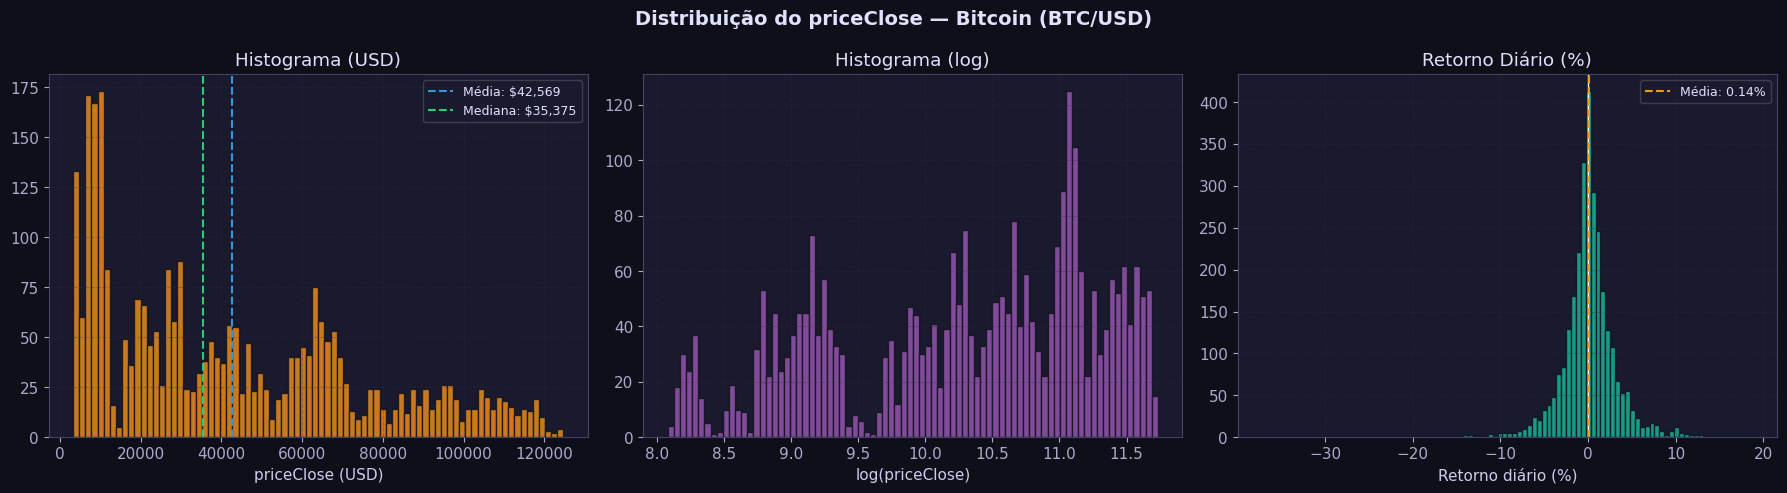

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0f0f1a')
fig.suptitle('Distribuição do priceClose — Bitcoin (BTC/USD)', 
             color='#e0e0ff', fontsize=14, fontweight='bold')

# Histograma (escala original)
axes[0].hist(df['priceClose'], bins=80, color='#f7931a', alpha=0.8, edgecolor='#0f0f1a')
axes[0].axvline(df['priceClose'].mean(),   color='#3498db', linestyle='--', linewidth=1.5, label=f'Média: ${df["priceClose"].mean():,.0f}')
axes[0].axvline(df['priceClose'].median(), color='#2ecc71', linestyle='--', linewidth=1.5, label=f'Mediana: ${df["priceClose"].median():,.0f}')
axes[0].set_title('Histograma (USD)', color='#e0e0ff')
axes[0].set_xlabel('priceClose (USD)')
axes[0].legend(framealpha=0.2, fontsize=9)
axes[0].grid(True, alpha=0.3)

# Histograma (escala log)
axes[1].hist(df['log_priceClose'], bins=80, color='#9b59b6', alpha=0.8, edgecolor='#0f0f1a')
axes[1].set_title('Histograma (log)', color='#e0e0ff')
axes[1].set_xlabel('log(priceClose)')
axes[1].grid(True, alpha=0.3)

# Histograma dos retornos diários
ret = df['daily_return'].dropna()
axes[2].hist(ret, bins=100, color='#1abc9c', alpha=0.8, edgecolor='#0f0f1a')
axes[2].axvline(0, color='#ffffff', linewidth=1)
axes[2].axvline(ret.mean(), color='#f39c12', linestyle='--', linewidth=1.5, label=f'Média: {ret.mean():.2f}%')
axes[2].set_title('Retorno Diário (%)', color='#e0e0ff')
axes[2].set_xlabel('Retorno diário (%)')
axes[2].legend(framealpha=0.2, fontsize=9)
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_06_distribuicoes.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 2. Análise de Sazonalidade por Componentes de Calendário

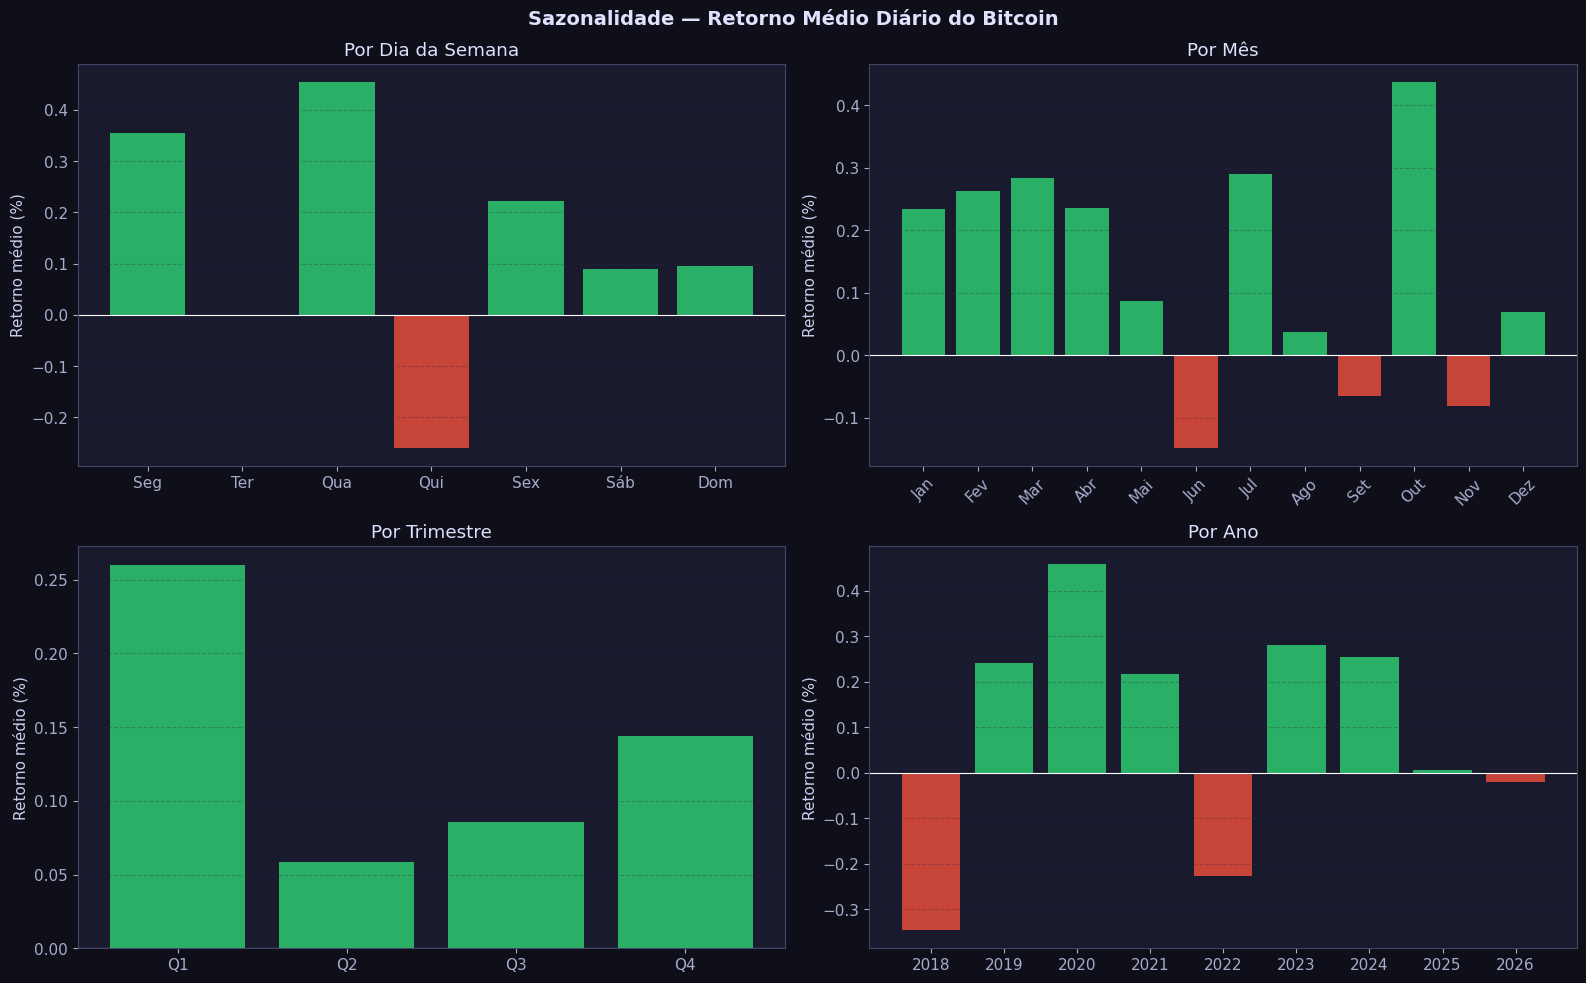

In [5]:
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month
df['day_of_week'] = df['date'].dt.dayofweek
df['quarter']     = df['date'].dt.quarter

dias_semana = ['Seg','Ter','Qua','Qui','Sex','Sáb','Dom']
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='#0f0f1a')
fig.suptitle('Sazonalidade — Retorno Médio Diário do Bitcoin', 
             color='#e0e0ff', fontsize=14, fontweight='bold')

ret_by_dow = df.groupby('day_of_week')['daily_return'].mean()
cores = ['#2ecc71' if v > 0 else '#e74c3c' for v in ret_by_dow.values]
axes[0,0].bar(range(7), ret_by_dow.values, color=cores, alpha=0.85)
axes[0,0].set_xticks(range(7))
axes[0,0].set_xticklabels(dias_semana)
axes[0,0].axhline(0, color='#ffffff', linewidth=0.8)
axes[0,0].set_title('Por Dia da Semana', color='#e0e0ff')
axes[0,0].set_ylabel('Retorno médio (%)')
axes[0,0].grid(True, alpha=0.3, axis='y')

ret_by_month = df.groupby('month')['daily_return'].mean()
cores = ['#2ecc71' if v > 0 else '#e74c3c' for v in ret_by_month.values]
axes[0,1].bar(range(1,13), ret_by_month.values, color=cores, alpha=0.85)
axes[0,1].set_xticks(range(1,13))
axes[0,1].set_xticklabels(meses, rotation=45)
axes[0,1].axhline(0, color='#ffffff', linewidth=0.8)
axes[0,1].set_title('Por Mês', color='#e0e0ff')
axes[0,1].set_ylabel('Retorno médio (%)')
axes[0,1].grid(True, alpha=0.3, axis='y')

ret_by_q = df.groupby('quarter')['daily_return'].mean()
cores = ['#2ecc71' if v > 0 else '#e74c3c' for v in ret_by_q.values]
axes[1,0].bar(['Q1','Q2','Q3','Q4'], ret_by_q.values, color=cores, alpha=0.85)
axes[1,0].axhline(0, color='#ffffff', linewidth=0.8)
axes[1,0].set_title('Por Trimestre', color='#e0e0ff')
axes[1,0].set_ylabel('Retorno médio (%)')
axes[1,0].grid(True, alpha=0.3, axis='y')

ret_by_year = df.groupby('year')['daily_return'].mean()
cores = ['#2ecc71' if v > 0 else '#e74c3c' for v in ret_by_year.values]
axes[1,1].bar(ret_by_year.index.astype(str), ret_by_year.values, color=cores, alpha=0.85)
axes[1,1].axhline(0, color='#ffffff', linewidth=0.8)
axes[1,1].set_title('Por Ano', color='#e0e0ff')
axes[1,1].set_ylabel('Retorno médio (%)')
axes[1,1].grid(True, alpha=0.3, axis='y')

for ax in axes.flat:
    ax.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_07_sazonalidade.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 3. Análise das Variáveis Externas

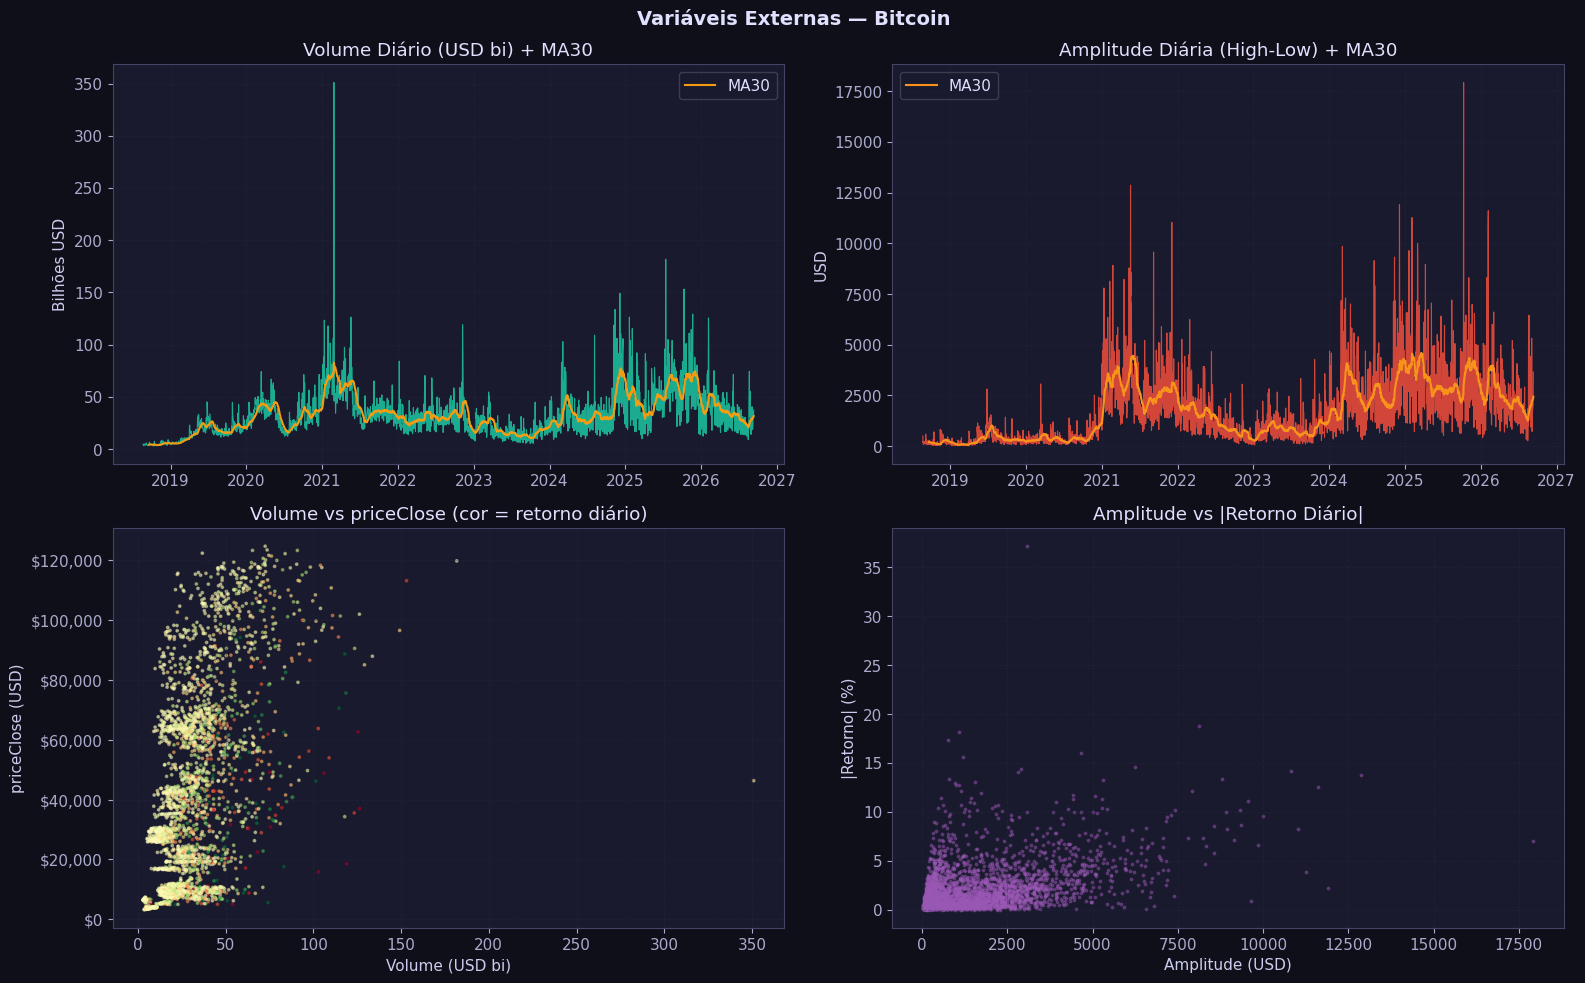

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='#0f0f1a')
fig.suptitle('Variáveis Externas — Bitcoin', color='#e0e0ff', fontsize=14, fontweight='bold')

# Volume
axes[0,0].plot(df['date'], df['volume']/1e9, color='#1abc9c', linewidth=0.8, alpha=0.9)
ma_vol = df['volume'].rolling(30).mean()
axes[0,0].plot(df['date'], ma_vol/1e9, color='#f39c12', linewidth=1.5, label='MA30')
axes[0,0].set_title('Volume Diário (USD bi) + MA30', color='#e0e0ff')
axes[0,0].set_ylabel('Bilhões USD')
axes[0,0].legend(framealpha=0.2)
axes[0,0].grid(True, alpha=0.3)

# Amplitude diária
axes[0,1].plot(df['date'], df['daily_range'], color='#e74c3c', linewidth=0.8, alpha=0.9)
ma_range = df['daily_range'].rolling(30).mean()
axes[0,1].plot(df['date'], ma_range, color='#f7931a', linewidth=1.5, label='MA30')
axes[0,1].set_title('Amplitude Diária (High-Low) + MA30', color='#e0e0ff')
axes[0,1].set_ylabel('USD')
axes[0,1].legend(framealpha=0.2)
axes[0,1].grid(True, alpha=0.3)

# Scatter: Volume vs priceClose
axes[1,0].scatter(df['volume']/1e9, df['priceClose'], 
                  c=df['daily_return'].clip(-10,10), cmap='RdYlGn',
                  s=3, alpha=0.5)
axes[1,0].set_title('Volume vs priceClose (cor = retorno diário)', color='#e0e0ff')
axes[1,0].set_xlabel('Volume (USD bi)')
axes[1,0].set_ylabel('priceClose (USD)')
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1,0].grid(True, alpha=0.3)

# Retorno vs amplitude (volatilidade)
axes[1,1].scatter(df['daily_range'], df['daily_return'].abs(), 
                  color='#9b59b6', s=3, alpha=0.4)
axes[1,1].set_title('Amplitude vs |Retorno Diário|', color='#e0e0ff')
axes[1,1].set_xlabel('Amplitude (USD)')
axes[1,1].set_ylabel('|Retorno| (%)')
axes[1,1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_facecolor('#1a1a2e')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y') if hasattr(ax.xaxis.get_major_formatter(), '__class__') and 'Date' in str(type(ax.xaxis.get_major_formatter())) else ax.xaxis.get_major_formatter())

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_08_variaveis_externas.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 4. Autocorrelação (ACF e PACF)

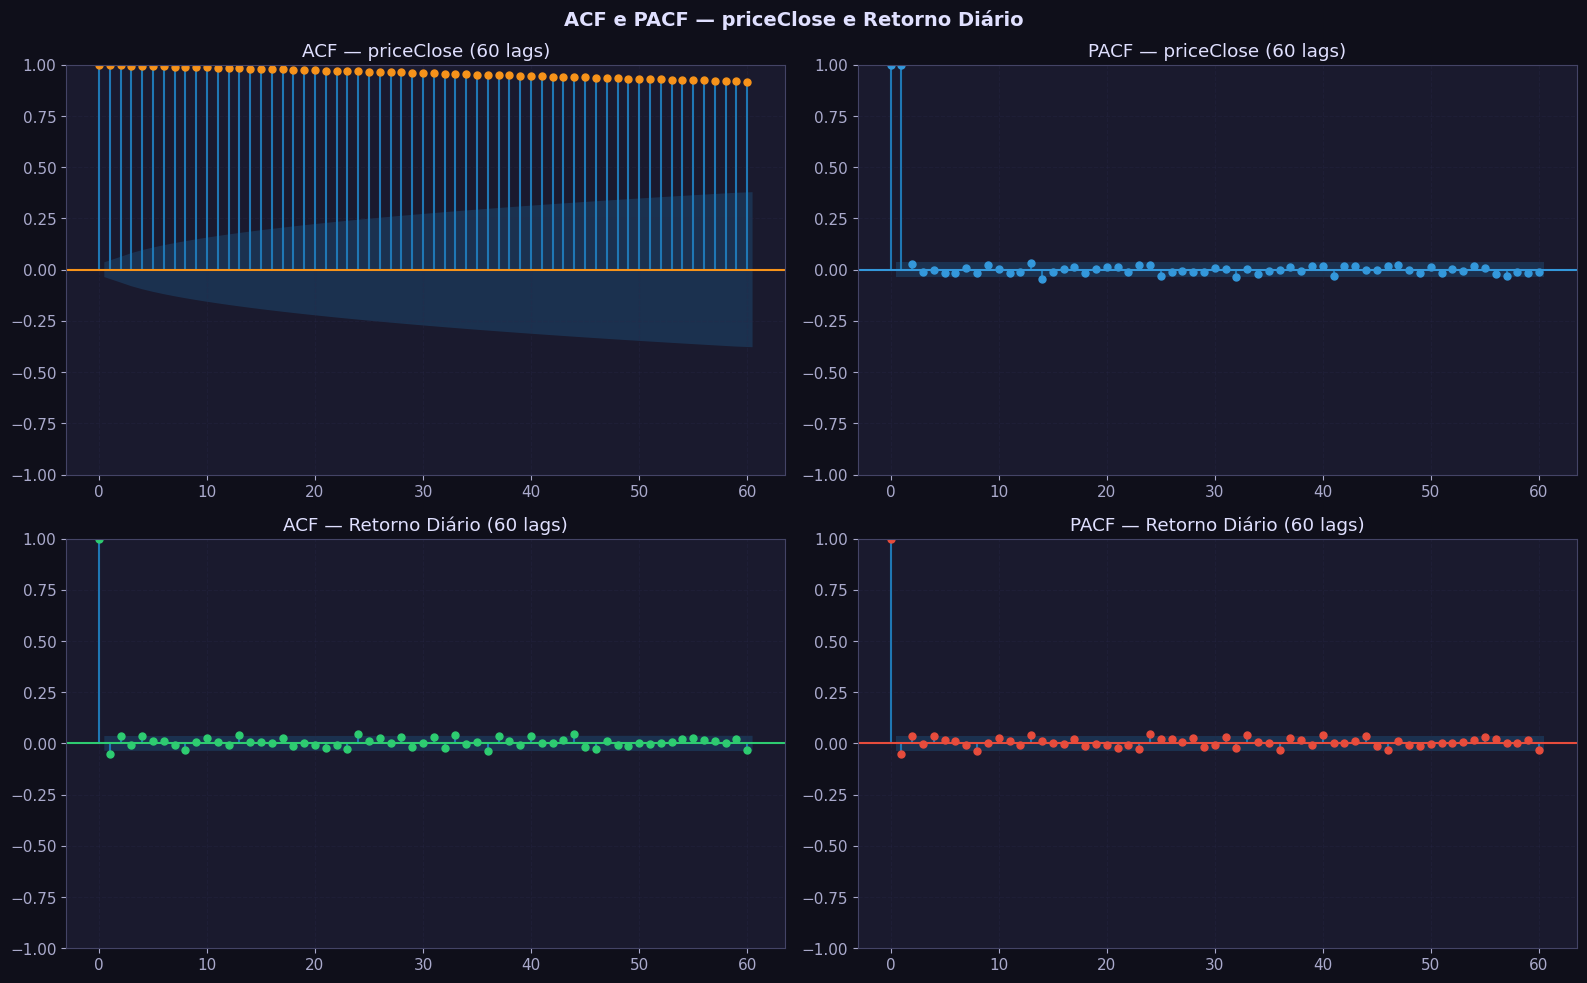

Interpretação:
- priceClose: alta autocorrelação persistente → série não-estacionária
- Retorno diário: autocorrelação praticamente zero → mais próximo de ruído branco
- ACF do retorno²: indicaria ARCH/GARCH (volatilidade agrupada)


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor='#0f0f1a')
fig.suptitle('ACF e PACF — priceClose e Retorno Diário', 
             color='#e0e0ff', fontsize=14, fontweight='bold')

serie_preco  = df['priceClose'].dropna()
serie_retorno = df['daily_return'].dropna()

# ACF - priceClose
plot_acf(serie_preco, lags=60, ax=axes[0,0], color='#f7931a', 
         title='ACF — priceClose (60 lags)')
axes[0,0].set_facecolor('#1a1a2e')
axes[0,0].title.set_color('#e0e0ff')

# PACF - priceClose
plot_pacf(serie_preco, lags=60, ax=axes[0,1], color='#3498db', method='ywm',
          title='PACF — priceClose (60 lags)')
axes[0,1].set_facecolor('#1a1a2e')
axes[0,1].title.set_color('#e0e0ff')

# ACF - retorno diário
plot_acf(serie_retorno, lags=60, ax=axes[1,0], color='#2ecc71',
         title='ACF — Retorno Diário (60 lags)')
axes[1,0].set_facecolor('#1a1a2e')
axes[1,0].title.set_color('#e0e0ff')

# PACF - retorno diário
plot_pacf(serie_retorno, lags=60, ax=axes[1,1], color='#e74c3c', method='ywm',
          title='PACF — Retorno Diário (60 lags)')
axes[1,1].set_facecolor('#1a1a2e')
axes[1,1].title.set_color('#e0e0ff')

for ax in axes.flat:
    ax.set_facecolor('#1a1a2e')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_09_acf_pacf.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

print('Interpretação:')
print('- priceClose: alta autocorrelação persistente → série não-estacionária')
print('- Retorno diário: autocorrelação praticamente zero → mais próximo de ruído branco')
print('- ACF do retorno²: indicaria ARCH/GARCH (volatilidade agrupada)')

## 5. Teste de Estacionariedade

In [8]:
def teste_estacionariedade(serie, nome):
    """Aplica ADF e KPSS e exibe resultados formatados."""
    print(f'\n{'='*50}')
    print(f' Série: {nome}')
    print(f"{'='*50}")
    
    # Teste ADF
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(serie.dropna(), autolag='AIC')
    print(f'\n[ADF] Estatística: {adf_stat:.4f} | p-valor: {adf_p:.4f}')
    print(f'       Valores críticos: 1%={adf_crit["1%"]:.4f}, 5%={adf_crit["5%"]:.4f}, 10%={adf_crit["10%"]:.4f}')
    adf_conclusion = '✅ Estacionária (rejeita H0)' if adf_p < 0.05 else '❌ Não-estacionária (não rejeita H0)'
    print(f'       Conclusão: {adf_conclusion}')
    
    # Teste KPSS
    kpss_stat, kpss_p, _, kpss_crit = kpss(serie.dropna(), regression='c', nlags='auto')
    print(f'\n[KPSS] Estatística: {kpss_stat:.4f} | p-valor: {kpss_p:.4f}')
    kpss_conclusion = '❌ Não-estacionária (rejeita H0)' if kpss_p < 0.05 else '✅ Estacionária (não rejeita H0)'
    print(f'       Conclusão: {kpss_conclusion}')

teste_estacionariedade(df['priceClose'], 'priceClose (nível)')
teste_estacionariedade(df['log_priceClose'], 'log(priceClose)')
teste_estacionariedade(df['daily_return'], 'Retorno Diário (%)')

print('\n' + '='*50)
print('INTERPRETAÇÃO GERAL:')
print('  priceClose em nível: não-estacionária (tendência de alta)')
print('  log(priceClose): também não-estacionária')
print('  Retorno diário: estacionária (diferenciação resolve a tendência)')
print('  → Para SARIMAX: usar d=1 (ou D=1 se sazonalidade) para diferenciar')
print('  → Para RF/XGBoost: lags e features de janela capturam a dinâmica')


 Série: priceClose (nível)

[ADF] Estatística: -1.2533 | p-valor: 0.6503
       Valores críticos: 1%=-3.4326, 5%=-2.8625, 10%=-2.5673
       Conclusão: ❌ Não-estacionária (não rejeita H0)

[KPSS] Estatística: 6.7157 | p-valor: 0.0100
       Conclusão: ❌ Não-estacionária (rejeita H0)

 Série: log(priceClose)

[ADF] Estatística: -1.2560 | p-valor: 0.6491
       Valores críticos: 1%=-3.4326, 5%=-2.8625, 10%=-2.5673
       Conclusão: ❌ Não-estacionária (não rejeita H0)

[KPSS] Estatística: 7.1520 | p-valor: 0.0100
       Conclusão: ❌ Não-estacionária (rejeita H0)

 Série: Retorno Diário (%)

[ADF] Estatística: -26.0070 | p-valor: 0.0000
       Valores críticos: 1%=-3.4326, 5%=-2.8625, 10%=-2.5673
       Conclusão: ✅ Estacionária (rejeita H0)

[KPSS] Estatística: 0.1533 | p-valor: 0.1000
       Conclusão: ✅ Estacionária (não rejeita H0)

INTERPRETAÇÃO GERAL:
  priceClose em nível: não-estacionária (tendência de alta)
  log(priceClose): também não-estacionária
  Retorno diário: estacionária

## 6. Boxplot por Ano — Evolução da Distribuição

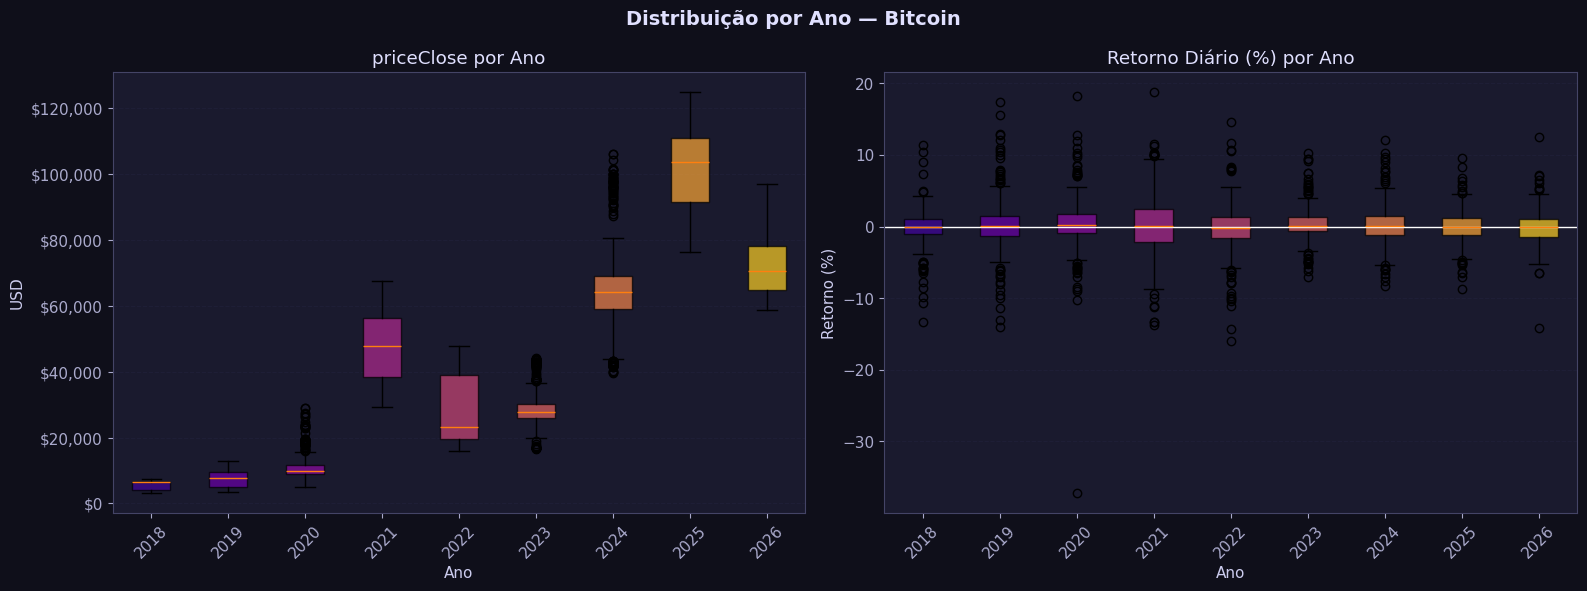

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0f0f1a')
fig.suptitle('Distribuição por Ano — Bitcoin', color='#e0e0ff', fontsize=14, fontweight='bold')

dados_por_ano = [df[df['year'] == y]['priceClose'].values for y in sorted(df['year'].unique())]
anos = sorted(df['year'].unique())

bp1 = axes[0].boxplot(dados_por_ano, labels=[str(y) for y in anos],
                       patch_artist=True, notch=False)
cores_box = plt.cm.plasma(np.linspace(0.1, 0.9, len(anos)))
for patch, cor in zip(bp1['boxes'], cores_box):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
axes[0].set_title('priceClose por Ano', color='#e0e0ff')
axes[0].set_ylabel('USD')
axes[0].set_xlabel('Ano')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Retorno por ano
ret_por_ano = [df[df['year'] == y]['daily_return'].dropna().values for y in anos]
bp2 = axes[1].boxplot(ret_por_ano, labels=[str(y) for y in anos],
                       patch_artist=True, notch=False)
for patch, cor in zip(bp2['boxes'], cores_box):
    patch.set_facecolor(cor)
    patch.set_alpha(0.7)
axes[1].axhline(0, color='#ffffff', linewidth=1)
axes[1].set_title('Retorno Diário (%) por Ano', color='#e0e0ff')
axes[1].set_ylabel('Retorno (%)')
axes[1].set_xlabel('Ano')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

for ax in axes:
    ax.set_facecolor('#1a1a2e')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_10_boxplot_ano.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 7. Volatilidade Condicional (Rolling Std)

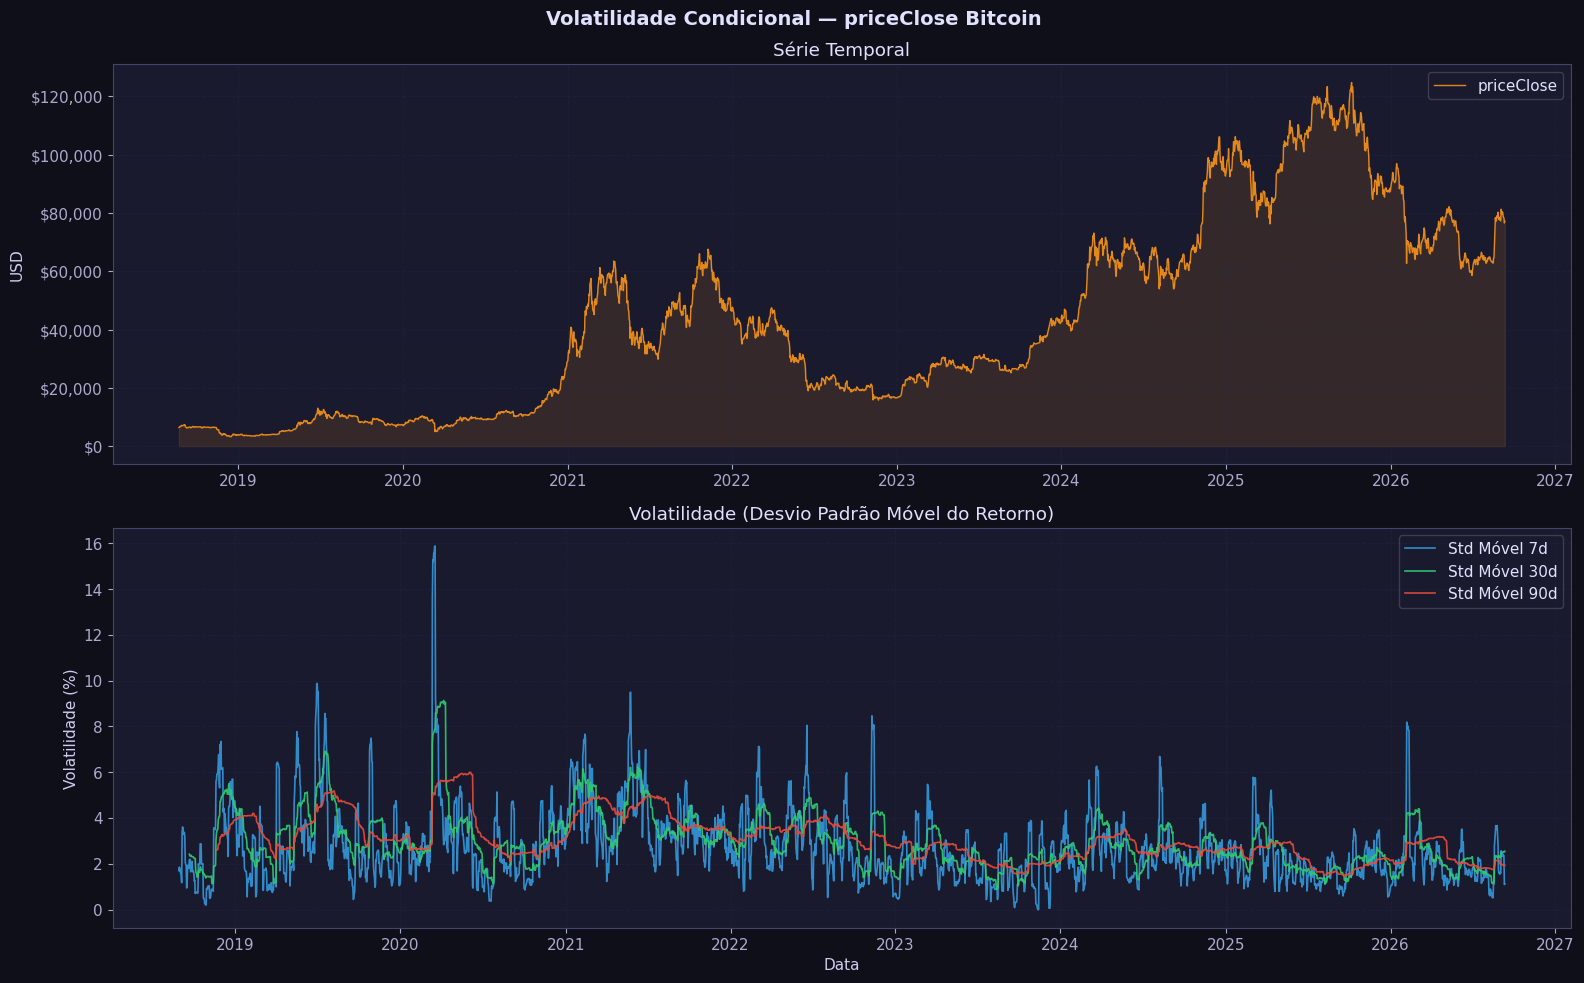

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), facecolor='#0f0f1a')
fig.suptitle('Volatilidade Condicional — priceClose Bitcoin', 
             color='#e0e0ff', fontsize=14, fontweight='bold')

# Série original
axes[0].plot(df['date'], df['priceClose'], color='#f7931a', linewidth=1, alpha=0.9, label='priceClose')
axes[0].fill_between(df['date'], df['priceClose'], alpha=0.12, color='#f7931a')
axes[0].set_title('Série Temporal', color='#e0e0ff')
axes[0].set_ylabel('USD')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(True, alpha=0.3)
axes[0].legend(framealpha=0.2)

# Volatilidade rolling (std do retorno)
for w, cor in [(7, '#3498db'), (30, '#2ecc71'), (90, '#e74c3c')]:
    vol = df['daily_return'].rolling(w).std()
    axes[1].plot(df['date'], vol, color=cor, linewidth=1.2, label=f'Std Móvel {w}d', alpha=0.9)

axes[1].set_title('Volatilidade (Desvio Padrão Móvel do Retorno)', color='#e0e0ff')
axes[1].set_ylabel('Volatilidade (%)')
axes[1].set_xlabel('Data')
axes[1].legend(framealpha=0.2)
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.set_facecolor('#1a1a2e')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'plot_11_volatilidade.png', dpi=150, bbox_inches='tight', facecolor='#0f0f1a')
plt.show()

## 8. Conclusões da EDA

| Insight | Impacto para Modelagem |
|---------|------------------------|
| Série não-estacionária (tendência forte) | SARIMAX: d=1; RF/XGBoost: features de lag e rolling |
| Alta volatilidade agrupada (clusters) | Adicionar features de volatilidade recente (rolling std) |
| Retorno diário próximo a ruído branco | Prever retorno é difícil; prever nível tem mais estrutura autocorrelada |
| Volume correlacionado com preço | Volume usável como variável externa (com lag) |
| Sazonalidade semanal e mensal fraca | Encoding cíclico incluído, mas peso pequeno esperado |
| Distribuição assimétrica do preço | Transformação log útil para análise residual |
| Halvings alteram estrutura da série | Indicadores de período podem ajudar modelos mais complexos |

**Próximo passo:** `05_STL_decomposicao.ipynb`